In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spacy
from spacy.matcher import PhraseMatcher


nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner", "textcat"]
)


def weak_label_corpus(
    df_res: pd.DataFrame,
    golden_list: list[str],
    batch_size: int = 1000,
):

    matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

    patterns = [
        nlp.make_doc(name.strip())
        for name in golden_list
        if isinstance(name, str) and name.strip()
    ]

    matcher.add("INSTRUMENT", patterns)

    known_docs = []
    unknown_docs = []

    # Extraer columnas una sola vez
    rows = list(
        df_res[["id", "content"]].itertuples(
            index=False,
            name=None
        )
    )

    texts = (text for _, text in rows)

    # spaCy procesa varios documentos conjuntamente
    for (doc_id, text), doc in zip(
        rows,
        nlp.pipe(texts, batch_size=batch_size)
    ):

        matches = matcher(doc)

        if not matches:
            unknown_docs.append({
                "doc_id": doc_id,
                "text": text,
            })
            continue

        # Obtener spans
        spans = [
            doc[start:end]
            for _, start, end in matches
        ]

        # Más largos primero
        spans.sort(
            key=lambda span: span.end_char - span.start_char,
            reverse=True,
        )

        # Eliminar overlaps
        selected = []

        for span in spans:
            if any(
                span.start_char < selected_span.end_char
                and span.end_char > selected_span.start_char
                for selected_span in selected
            ):
                continue

            selected.append(span)

        known_docs.append({
            "doc_id": doc_id,
            "text": text,
            "spans": [
                (
                    span.start_char,
                    span.end_char,
                    span.text,
                )
                for span in selected
            ],
        })

    return known_docs, unknown_docs

    
def build_golden_list(df_instrument: pd.DataFrame) -> list[str]:
    """
    Build the backbone of the weak labelling.

    Official titles and aliases receive the same treatment. Either the
    official name or an alias can be used in training. The train/eval
    partition should therefore be based on this list rather than on
    individual entities.

    Parameters
    ----------
    df_instrument:
        DataFrame containing at least ["title", "alternative_name", ...].

    Returns
    -------
    list[str]
        Names (official titles and alternative names) that the
        PhraseMatcher should detect.
    """
    if df_instrument.empty:
        return []

    golden_list = []

    # Official titles
    titles = [
        t.strip()
        for t in df_instrument["title"].dropna()
        if t.strip()
    ]

    # Alternative names
    aliases = []
    for value in df_instrument["alternative_name"].dropna():
        aliases.extend(
            p.strip()
            for p in value.split(";")
            if p.strip()
        )

    golden_list.extend(titles)
    golden_list.extend(aliases)

    return golden_list

In [2]:
# ============================================================
# 1. LOAD RESOLUTIONS + BUILD GOLDEN LIST
# ============================================================

# ------------------------------------------------------------
# Resolutions
# ------------------------------------------------------------

DEFAULT_DOC_DF = "/home/user/branes/NER-data/ga_resolutions_1946_2025.csv"

WIKI_CSV = "/home/user/branes/NER-data/wiki-treaties_formatted.csv"
OHCHR_CSV = "/home/user/branes/NER-data/ohchr_instruments_detailed-instit.csv"
UNO_CSV = "/home/user/branes/NER-data/UNO-Treaties.csv"
UNESCO_CSV = "/home/user/branes/NER-data/UNESCO_legal_instruments_detail.csv"
CONV_PROT_REC_CSV = "/home/user/branes/NER-data/conventions-protocols-recommendations.csv"

df_res = pd.read_csv(DEFAULT_DOC_DF)
df_res = df_res.rename(columns={"res_id2": "id"})

# Parse resolution date: DD Month YYYY
df_res["date_parsed"] = pd.to_datetime(
    df_res["date_c"],
    format="%d %B %Y",
    errors="coerce"
)

df_res["year"] = df_res["date_parsed"].dt.year

print("Resolutions:", len(df_res))
print("Date range:", df_res["date_parsed"].min(), "→", df_res["date_parsed"].max())
print("Year range:", df_res["year"].min(), "→", df_res["year"].max())


# ------------------------------------------------------------
# Instrument reference tables
# ------------------------------------------------------------
cols = ["title", "year", "alternative_name"]

# Wikipedia
df_wiki = pd.read_csv(WIKI_CSV)
df_wiki = df_wiki.rename(
    columns={
        "name": "title",
        "cleaned_note": "alternative_name"
    }
)[cols]

# OHCHR
df_ohchr = pd.read_csv(OHCHR_CSV)
df_ohchr["year"] = pd.to_datetime(
    df_ohchr["adoption_date"],
    format="%d %B %Y",
    errors="coerce"
).dt.year
df_ohchr["alternative_name"] = ""
df_ohchr = df_ohchr[cols]

# UNO Treaties
df_uno = pd.read_csv(UNO_CSV)
df_uno["year"] = pd.to_datetime(
    df_uno["date"],
    format="%d %B %Y",
    errors="coerce"
).dt.year
df_uno["alternative_name"] = ""
df_uno = df_uno[cols]

# UNESCO
df_unesco = pd.read_csv(UNESCO_CSV)
df_unesco["year"] = pd.to_datetime(
    df_unesco["date"],
    format="%d %B %Y",
    errors="coerce"
).dt.year
df_unesco["alternative_name"] = ""
df_unesco = df_unesco[cols]

# Conventions / protocols / recommendations
df_conv_prot_rec = pd.read_csv(CONV_PROT_REC_CSV)
df_conv_prot_rec["alternative_name"] = ""
df_conv_prot_rec = df_conv_prot_rec[cols]


# ------------------------------------------------------------
# Combined instrument reference table
# ------------------------------------------------------------
df_instrument = pd.concat(
    [
        df_wiki,
        df_ohchr,
        df_uno,
        df_unesco,
        df_conv_prot_rec
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Golden list
# ------------------------------------------------------------
golden_list = build_golden_list(df_instrument)

# Remove duplicates while preserving order
golden_list = list(dict.fromkeys(
    x.strip()
    for x in golden_list
    if isinstance(x, str) and x.strip()
))

print("Reference rows:", len(df_instrument))
print("Golden-list names / aliases:", len(golden_list))

# Quick inspection
pd.Series(golden_list, name="instrument").head(20)

Resolutions: 21903
Date range: 1946-01-24 00:00:00 → 2025-03-04 00:00:00
Year range: 1946 → 2025
Reference rows: 1394
Golden-list names / aliases: 1414


0                                       Treaty of Paris
1                                  Treaty of Washington
2     Convention for the Preservation of Wild Animal...
3                                 Hay–Pauncefote Treaty
4                                        Boxer Protocol
5                               Anglo-Japanese Alliance
6                                 Treaty of Vereeniging
7             Cuban–American Treaty of Relations (1903)
8                                     Hay–Herrán Treaty
9                                    Hay–Herbert Treaty
10                             Hay–Bunau-Varilla Treaty
11                                 Treaty of Petrópolis
12             Southern African Customs Union Agreement
13                    International Sanitary Convention
14                Treaty of Peace and Friendship (1904)
15                                      Treaty of Lhasa
16                                 Treaty of Portsmouth
17                                     Treaty of

In [3]:
# ============================================================
# 2. TEMPORAL COVERAGE OF THE GOLDEN LIST
# ============================================================

# Run weak labeling on the full resolution corpus
known_docs, unknown_docs = weak_label_corpus(
    df_res,
    golden_list
)

print(f"Known docs:   {len(known_docs):,}")
print(f"Unknown docs: {len(unknown_docs):,}")

Known docs:   11,798
Unknown docs: 10,105
Total matched mentions: 50237
Distinct matched names: 357
Golden-list names: 1,405
Recognized only from 2000 onward: 9.96%


In [12]:
# ------------------------------------------------------------
# Collect instrument mentions + resolution year
# ------------------------------------------------------------
mentions = []

for doc in known_docs:
    doc_id = doc["doc_id"]

    # Get resolution year
    year = df_res.loc[df_res["id"] == doc_id, "year"]

    if year.empty or pd.isna(year.iloc[0]):
        continue

    year = int(year.iloc[0])

    for start, end, matched_text in doc["spans"]:
        mentions.append({
            "doc_id": doc_id,
            "year": year,
            "instrument": matched_text.strip(),
            "instrument_norm": matched_text.strip().casefold()
        })

df_mentions = pd.DataFrame(mentions)

print("Total matched mentions:", len(df_mentions))
print("Distinct matched names:", df_mentions["instrument_norm"].nunique())


# ------------------------------------------------------------
# Golden list as dataframe
# ------------------------------------------------------------
df_golden = pd.DataFrame({
    "instrument": golden_list
})

df_golden["instrument_norm"] = (
    df_golden["instrument"]
    .str.strip()
    .str.casefold()
)

# Defensive deduplication
df_golden = df_golden.drop_duplicates("instrument_norm").reset_index(drop=True)


# ------------------------------------------------------------
# First / last recognition year
# ------------------------------------------------------------
recognition_years = (
    df_mentions
    .groupby("instrument_norm")["year"]
    .agg(
        first_year="min",
        last_year="max",
        n_years="nunique",
        n_mentions="size"
    )
    .reset_index()
)

df_golden = df_golden.merge(
    recognition_years,
    on="instrument_norm",
    how="left"
)


# ------------------------------------------------------------
# Pre/post-2010 flags
# ------------------------------------------------------------
flags = (
    df_mentions
    .groupby("instrument_norm")["year"]
    .agg(
        has_pre_2010=lambda s: (s < 2010).any(),
        has_post_2010=lambda s: (s >= 2010).any()
    )
    .reset_index()
)

df_golden = df_golden.merge(
    flags,
    on="instrument_norm",
    how="left"
)

df_golden["has_pre_2010"] = df_golden["has_pre_2010"].fillna(False)
df_golden["has_post_2010"] = df_golden["has_post_2010"].fillna(False)

# ------------------------------------------------------------
# Classification
# ------------------------------------------------------------
df_golden["recognition_period"] = np.select(
    [
        (~df_golden["has_pre_2010"]) & (~df_golden["has_post_2010"]),
        ( df_golden["has_pre_2010"]) & (~df_golden["has_post_2010"]),
        (~df_golden["has_pre_2010"]) & ( df_golden["has_post_2010"]),
        ( df_golden["has_pre_2010"]) & ( df_golden["has_post_2010"]),
    ],
    [
        "never recognized",
        "pre-2010 only",
        "2010+ only",
        "both periods"
    ],
    default="unknown"
)


# ------------------------------------------------------------
# Main percentage
# ------------------------------------------------------------
n_golden = len(df_golden)

pct_only_post_2010 = (
    100
    * (df_golden["recognition_period"] == "2010+ only").sum()
    / n_golden
)

print(f"Golden-list names: {n_golden:,}")
print(f"Recognized only from 2010 onward: {pct_only_post_2010:.2f}%")


# ------------------------------------------------------------
# First recognition: pre-2010 vs 2010+
# ------------------------------------------------------------

df_recognized = df_golden[
    df_golden["first_year"].notna()
].copy()

df_recognized["first_recognition_period"] = np.where(
    df_recognized["first_year"] < 2010,
    "pre-2010",
    "2010+"
)

counts = df_recognized["first_recognition_period"].value_counts()

n_recognized = len(df_recognized)

pct_pre_2010 = 100 * counts.get("pre-2010", 0) / n_recognized
pct_post_2010 = 100 * counts.get("2010+", 0) / n_recognized

print("\n--- First recognition among observed instruments ---")
print(f"Observed instruments: {n_recognized:,}")
print(f"First seen pre-2010:   {counts.get('pre-2010', 0):,} "
      f"({pct_pre_2010:.2f}%)")
print(f"First seen 2010+:      {counts.get('2010+', 0):,} "
      f"({pct_post_2010:.2f}%)")

Total matched mentions: 50237
Distinct matched names: 357
Golden-list names: 1,405
Recognized only from 2010 onward: 6.33%

--- First recognition among observed instruments ---
Observed instruments: 354
First seen pre-2010:   265 (74.86%)
First seen 2010+:      89 (25.14%)


In [4]:
summary = (
    df_golden["recognition_period"]
    .value_counts()
    .rename_axis("recognition_period")
    .to_frame("n")
)

summary["pct"] = 100 * summary["n"] / len(df_golden)

summary

,n,pct
recognition_period,,
never recognized,1051,74.804270
both periods,146,10.391459
2000+ only,140,9.964413
pre-2000 only,68,4.839858


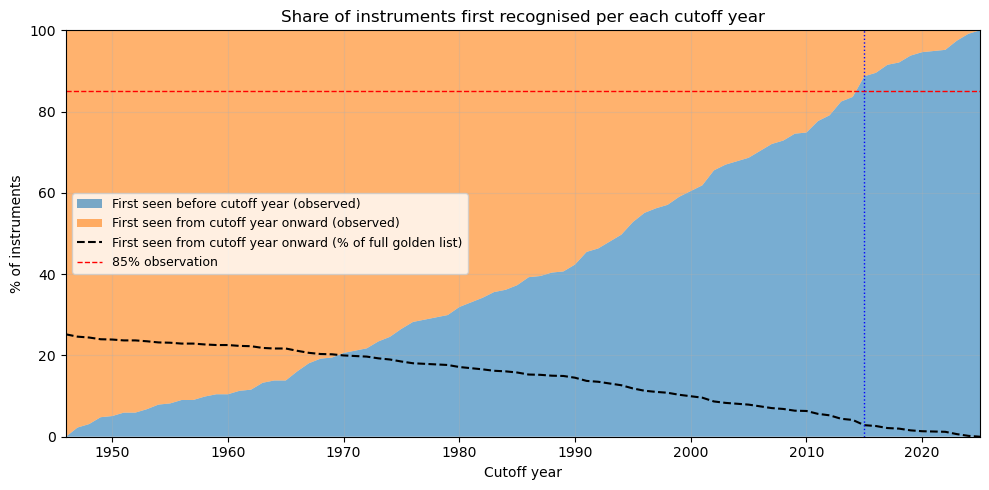

85% of observed instruments were first seen before 2015


In [26]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Share of instruments first seen before / from each cutoff year
# ------------------------------------------------------------
years = np.arange(df_mentions["year"].min(), df_mentions["year"].max() + 1)

first_year_all = df_golden["first_year"]           # NaN = never seen
first_year_obs = first_year_all.dropna()           # observed instruments only
n_obs = len(first_year_obs)

df_curve = pd.DataFrame({
    "cutoff_year": years,
    # relative to observed instruments (the bracketed % in your output)
    "pct_pre_obs":  [100 * (first_year_obs <  y).sum() / n_obs for y in years],
    "pct_post_obs": [100 * (first_year_obs >= y).sum() / n_obs for y in years],
    # relative to the whole golden list (the 6.33% in your output)
    # NaN >= y evaluates to False, so never-seen names are excluded automatically
    "pct_post_golden": [100 * (first_year_all >= y).sum() / n_golden for y in years],
})

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

ax.stackplot(
    df_curve["cutoff_year"],
    df_curve["pct_pre_obs"],
    df_curve["pct_post_obs"],
    labels=["First seen before cutoff year (observed)",
            "First seen from cutoff year onward (observed)"],
    alpha=0.6,
)

ax.plot(
    df_curve["cutoff_year"], df_curve["pct_post_golden"],
    "k--", lw=1.5,
    label="First seen from cutoff year onward (% of full golden list)",
)


ax.set_xlabel("Cutoff year")
ax.set_ylabel("% of instruments")
ax.set_ylim(0, 100)
ax.set_xlim(years.min(), years.max())
ax.set_title("Share of instruments first recognised per each cutoff year")
ax.grid(alpha=0.3)
plt.tight_layout()

target = 85
year_85 = df_curve.loc[df_curve["pct_pre_obs"] > target, "cutoff_year"].min()

ax.axhline(target, color="red", ls="--", lw=1, label="85% observation")
ax.axvline(year_85, color="blue", ls=":", lw=1)
ax.legend(loc="center left", fontsize=9)
plt.show()

print(f"{target}% of observed instruments were first seen before {year_85}")


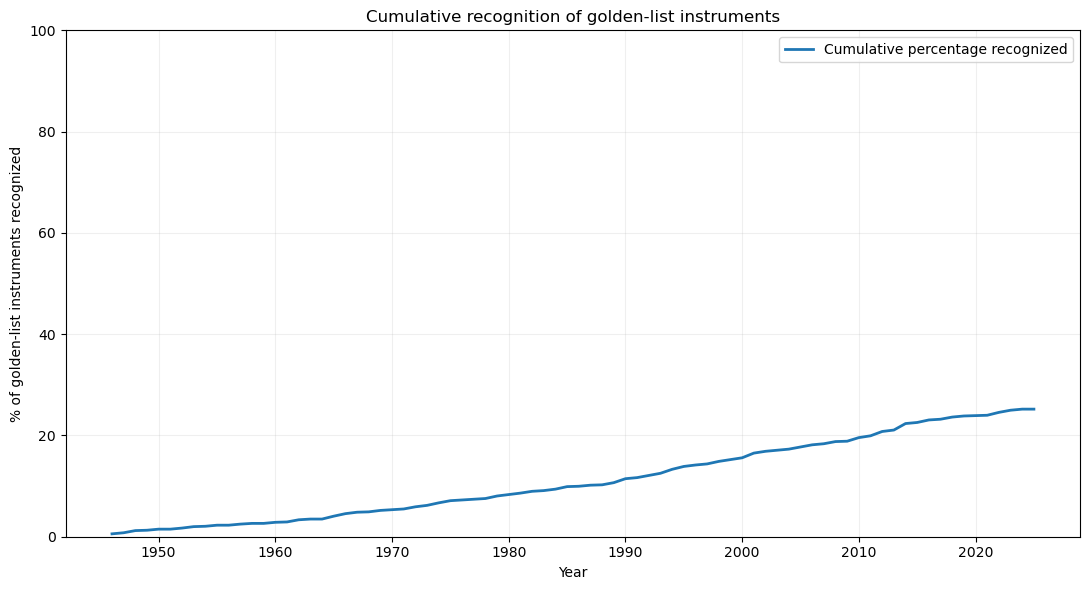

In [10]:
# ============================================================
# 3. CUMULATIVE RECOGNITION CURVE
# ============================================================

years = np.arange(
    int(df_res["year"].min()),
    int(df_res["year"].max()) + 1
)

coverage = []

for year in years:
    recognized = (
        df_golden["first_year"].notna()
        & (df_golden["first_year"] <= year)
    ).sum()

    coverage.append(
        100 * recognized / len(df_golden)
    )

df_coverage = pd.DataFrame({
    "year": years,
    "pct_instruments_recognized": coverage
})


# Plot
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df_coverage["year"],
    df_coverage["pct_instruments_recognized"],
    linewidth=2,
    label="Cumulative percentage recognized"
)

ax.set_xlabel("Year")
ax.set_ylabel("% of golden-list instruments recognized")
ax.set_title("Cumulative recognition of golden-list instruments")
ax.set_ylim(0, 100)
ax.grid(alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

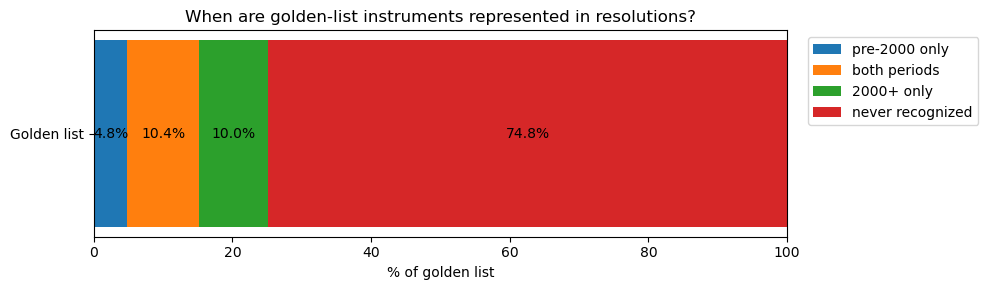

In [6]:
# ============================================================
# 4. PRE-2000 / POST-2000 COMPOSITION
# ============================================================

order = [
    "pre-2000 only",
    "both periods",
    "2000+ only",
    "never recognized"
]

composition = (
    df_golden["recognition_period"]
    .value_counts()
    .reindex(order, fill_value=0)
)

composition_pct = 100 * composition / len(df_golden)

fig, ax = plt.subplots(figsize=(10, 3))

left = 0

for category in order:
    value = composition_pct[category]

    ax.barh(
        ["Golden list"],
        [value],
        left=left,
        label=category
    )

    if value > 4:
        ax.text(
            left + value / 2,
            0,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

    left += value

ax.set_xlim(0, 100)
ax.set_xlabel("% of golden list")
ax.set_title("When are golden-list instruments represented in resolutions?")
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

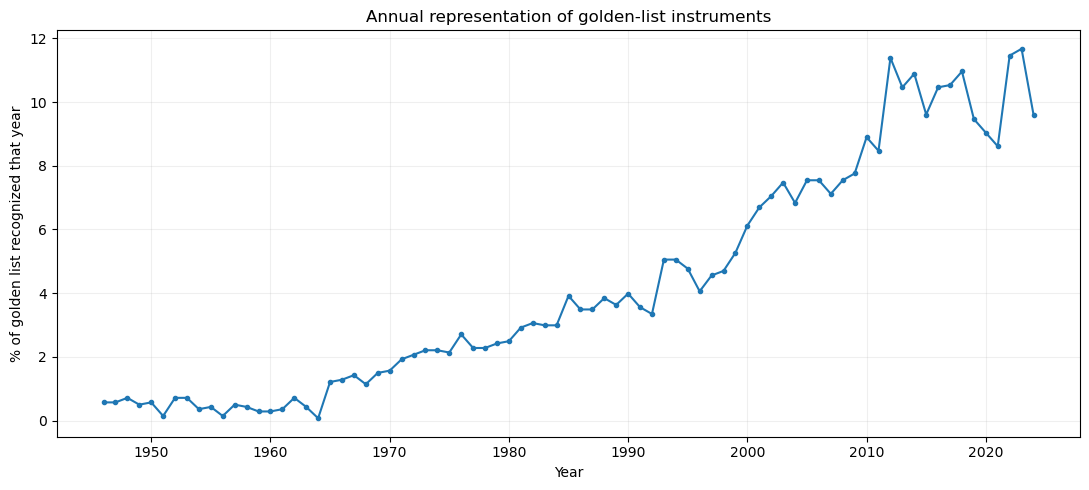

In [8]:
annual_recognition = (
    df_mentions
    .groupby("year")["instrument_norm"]
    .nunique()
    .div(len(df_golden))
    .mul(100)
    .reset_index(name="pct_golden_recognized")
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    annual_recognition["year"].iloc[:-1],
    annual_recognition["pct_golden_recognized"].iloc[:-1],
    marker="o",
    markersize=3
)

"""
ax.axvline(
    2000,
    linestyle="--",
    linewidth=1.5
)
"""

ax.set_xlabel("Year")
ax.set_ylabel("% of golden list recognized that year")
ax.set_title("Annual representation of golden-list instruments")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()